## Importing the needed libraries 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [17]:
df = pd.read_csv('../data/raw/sales_dataset.csv')
print(df.shape)
df.head(3)

(10000, 21)


,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI


- The dataset has 10000 rows, and 21 columns. 
- The columns containing Ids are alphanumeric. 

### Basic Data exploration

In [18]:
print("Column Names, and Data Types:\n")
print(df.dtypes)

Column Names, and Data Types:

order_id              str
order_date            str
ship_date             str
delivery_date         str
order_status          str
customer_id           str
customer_name         str
country               str
state                 str
city                  str
product_id            str
product_name          str
category              str
sub_category          str
brand                 str
quantity            int64
unit_price        float64
discount          float64
shipping_cost     float64
total_sales       float64
payment_method        str
dtype: object


- The columns names are in lowercase, and well formated for the analysis.
- The dates are in string, I need to change them into date datatypes. 

## Summary Statistics 

In [19]:
print("Summary Statistics:\n")
print(df.describe())

print("\nUnique Values Count for Key Columns:")
print(f"Total Orders: {df['order_id'].nunique()}")
print(f"Total Customers: {df['customer_id'].nunique()}")
print(f"Total Products: {df['product_id'].nunique()}")
print(f"Categories: {df['category'].unique().tolist()}")
print(f"Sub-Categories: {df['sub_category'].unique().tolist()}")

Summary Statistics:

          quantity    unit_price      discount  shipping_cost    total_sales
count  10000.00000  10000.000000  10000.000000   10000.000000   10000.000000
mean       3.01440  25126.511133      0.149968      85.053192   64212.910555
std        1.42035  14343.922332      0.086828      37.575284   50992.635082
min        1.00000    214.200000      0.000000      20.010000     309.939600
25%        2.00000  12657.827500      0.070000      52.507500   24037.196775
50%        3.00000  24880.490000      0.150000      84.995000   50287.177500
75%        4.00000  37544.640000      0.220000     117.680000   93417.891825
max        5.00000  49981.880000      0.300000     149.950000  249155.530000

Unique Values Count for Key Columns:
Total Orders: 10000
Total Customers: 6016
Total Products: 900
Categories: ['Home', 'Electronics', 'Fashion']
Sub-Categories: ['Furniture', 'Laptop', 'Kitchen', 'Mobile', 'Clothing', 'Accessories', 'Footwear']


- We have 6016 unique customers, 900 unique products, and 3 categories. 

## Data Quality Analysis

In [20]:
print("\nMissing Values:\n")
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values)
else:
    print("No missing values found. \n")

print("Duplicate Rows Count:")
duplicated_values = df.duplicated().sum()
if duplicated_values > 0:
    print(duplicated_values)
else:
    print("No duplicate rows found. \n")


Missing Values:

No missing values found. 

Duplicate Rows Count:
No duplicate rows found. 



In [21]:
print("Invalid or Inconsistent Values:\n")
print(f"Order Statuses: {df['order_status'].unique().tolist()}")
print(f"Payment Methods: {df['payment_method'].unique().tolist()}")
print(f"Quantity Range: Min = {df['quantity'].min()}, Max = {df['quantity'].max()}")

Invalid or Inconsistent Values:

Order Statuses: ['Delivered']
Payment Methods: ['Card', 'COD', 'UPI', 'NetBanking']
Quantity Range: Min = 1, Max = 5


- Our 10000 data is the record of the delivered only
- There is no invalid, or null payment methods 

In [22]:
print("Outlier Detection (IQR Method): \n")
for col in ['total_sales', 'unit_price', 'shipping_cost']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Outliers in {col}: {outlier_count}")

Outlier Detection (IQR Method): 

Outliers in total_sales: 163
Outliers in unit_price: 0
Outliers in shipping_cost: 0


- There are 163 outliers in total_sales, while unit_price, and shipping cost have zero. The total_sales is unit_price*qualtity, hence the qualtity ranges min 1 to max 5. This created a slide high and low total_sales. 

## Exploratory Analysis

In [23]:
# Sales by category
category_sales = df.groupby('category')['total_sales'].sum().apply('{:,.2f}'.format).reset_index()
print("\nTotal Sales by Category:")
display(category_sales)

# Average order value
aov = df['total_sales'].mean()
print(f"\nAverage Order Value (AOV): {aov:.2f} \n")

# Filtering rows based on specific conditions ( Electronics category with high quantity)
filtered_sales = df[(df['category'] == 'Electronics') & (df['quantity'] >= 4)]
print(f"Filtered rows count: {filtered_sales.shape[0]}")
display(filtered_sales.head(3))

# Using .iloc[] for positional slicing; selecting specific rows 0 to 4 and columns 0 to 5
subset_iloc = df.iloc[0:5, 0:5]
print("\nUsing .iloc[] to slice rows 0-4 and columns 0-4:")
display(subset_iloc)


Total Sales by Category:


,category,total_sales
0,Electronics,"219,356,274.74"
1,Fashion,"208,009,064.75"
2,Home,"214,763,766.06"



Average Order Value (AOV): 64212.91 

Filtered rows count: 1391


,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
6,A10006,2026-01-04,2026-01-10,2026-01-21,Delivered,C9866,Heather Campos,India,Colorado,Turnerville,...,page,Electronics,Mobile,Wade-Jackson,4,41577.60,0.06,29.90,156361.6760,COD
8,A10008,2026-02-09,2026-02-03,2026-01-01,Delivered,C4823,Theresa Collins,India,Maryland,Coreystad,...,like,Electronics,Mobile,"Silva, White and Bates",5,12891.02,0.03,99.08,62620.5270,COD



Using .iloc[] to slice rows 0-4 and columns 0-4:


,order_id,order_date,ship_date,delivery_date,order_status
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered


## visualization: Sales by Category Bar Chart

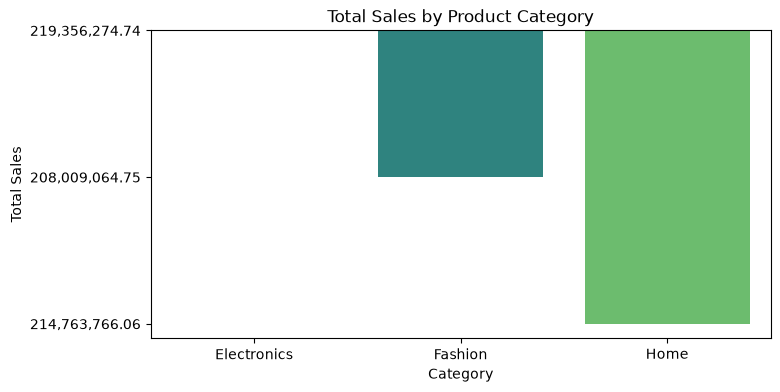

In [31]:
plt.figure(figsize=(8, 4))
sns.barplot(data=category_sales, x='category', y='total_sales', hue='category', palette='viridis', legend=False)
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

# Data Cleaning and Transformation

## Converting dates into proper date datatype

In [25]:
date_cols = ['order_date', 'ship_date', 'delivery_date']
df[date_cols] = df[date_cols].apply(pd.to_datetime)
print(df[date_cols].dtypes)

order_date       datetime64[us]
ship_date        datetime64[us]
delivery_date    datetime64[us]
dtype: object
